# ***AI/ML Task: Voice-Based Cognitive Decline Pattern Detection***

1. Install Required Packages

In [38]:
# Run these once in the notebook or install them via terminal before starting
!pip install librosa pydub SpeechRecognition webrtcvad
!pip install nltk spacy scikit-learn matplotlib seaborn pandas numpy
!python -m nltk.downloader all
!python -m spacy download en_core_web_sm


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]  

 2. Import Libraries and Setup

In [39]:
import librosa
import librosa.display
import speech_recognition as sr
from pydub import AudioSegment
import webrtcvad

import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Load NLP models
nlp = spacy.load("en_core_web_sm")
nltk.download("punkt")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

**3. Upload & List Audio Files**

In [40]:
from google.colab import files
uploaded = files.upload()  # Select 5–10 .wav files

os.makedirs("voice_clips", exist_ok=True)

for filename in uploaded:
    os.rename(filename, f"voice_clips/{filename}")

# List files
AUDIO_DIR = "voice_clips"
audio_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
print("Uploaded files:", audio_files)


Saving 14 Apr, 3.35 pm_.wav to 14 Apr, 3.35 pm_.wav
Saving 14 Apr, 3.36 pm_.wav to 14 Apr, 3.36 pm_.wav
Saving 14 Apr, 3.14 pm_(2).wav to 14 Apr, 3.14 pm_(2) (1).wav
Saving 14 Apr, 3.14 pm_.wav to 14 Apr, 3.14 pm_ (1).wav
Saving harvard.wav to harvard (1).wav
Saving self-destruction-sequence-initiated-robotic-female-tomas-herudek-1-00-05.wav to self-destruction-sequence-initiated-robotic-female-tomas-herudek-1-00-05 (1).wav
Saving i-will-have-my-revenge-robot-male-epic-stock-media-1-00-03.wav to i-will-have-my-revenge-robot-male-epic-stock-media-1-00-03 (1).wav
Saving oh-my-god-female-gfx-sounds-1-1-00-01.wav to oh-my-god-female-gfx-sounds-1-1-00-01 (1).wav
Saving sample-pack-links-in-bio-sampled-stuff-288267.wav to sample-pack-links-in-bio-sampled-stuff-288267 (1).wav
Saving hol-up-voice-one-shot-77742.wav to hol-up-voice-one-shot-77742 (1).wav
Saving 086299_pinkie-pie-have-a-cupcakewav-86111.wav to 086299_pinkie-pie-have-a-cupcakewav-86111 (1).wav
Saving catgirl-saying-quotwhisker-a-

**`** 4. Transcribe Audio to Text**`**

In [41]:
recognizer = sr.Recognizer()

def transcribe_audio(file_path):
    with sr.AudioFile(file_path) as source:
        audio = recognizer.record(source)
        try:
            return recognizer.recognize_google(audio)
        except sr.UnknownValueError:
            return ""
        except sr.RequestError:
            return ""

transcriptions = {}
for f in audio_files:
    path = os.path.join(AUDIO_DIR, f)
    transcriptions[f] = transcribe_audio(path)

# View transcripts
for fname, text in transcriptions.items():
    print(f"\n{fname}: {text}")



catgirl-saying-quotwhisker-a-secret-in-my-ear-nyaquot-230765 (1).wav: whisker a secret in my ear now

14 Apr, 3.35 pm_.wav: good morning everyone today I want to talk briefly about our CL

self-destruction-sequence-initiated-robotic-female-tomas-herudek-1-00-05 (1).wav: self destruction sequence initiated

beta-test-female-spoken-vocal_79bpm (1).wav: 

harvard (1).wav: does snail smell of old beer lingers it takes heat to bring out the odor a cold dip restores health and zest a salt pickle taste fine with ham tacos al pastor are my favorite a zestful food is the hot cross bun

14 Apr, 3.36 pm_.wav: saving energy reduce waste on planting trees and using clean transport together we can make a difference and protect our planet from future Generations

oh-my-god-female-gfx-sounds-1-1-00-01 (1).wav: oh my God

i-will-have-my-revenge-robot-male-epic-stock-media-1-00-03 (1).wav: I will have my revenge

086299_pinkie-pie-have-a-cupcakewav-86111 (1).wav: 

adam-neely-spoken-vocals_109bpm (1).w

**5. Extract Audio & NLP Features**

In [47]:
import re
import librosa
import numpy as np
import speech_recognition as sr

def extract_audio_features(file_path, text):
    # Load the audio
    y, sr = librosa.load(file_path)
    duration = librosa.get_duration(y=y, sr=sr)

    # Basic features
    speech_rate = len(text.split()) / duration if duration > 0 else 0
    pitch = librosa.yin(y, fmin=50, fmax=300)
    pitch_var = np.std(pitch)

    # Hesitation detection
    hesitation_words = ['um', 'uh', 'erm', 'ah', 'like', 'you know', 'so']
    hesitations = sum(len(re.findall(r'\b' + hw + r'\b', text.lower())) for hw in hesitation_words)

    # Pause detection: Improved method using word count and sentence structure
    # Using a basic idea that pauses usually happen between punctuation marks or long gaps between words.
    pauses = sum(1 for word in text.split() if word in ['.', ',', '?', '!', '...', '—'])

    # Return the feature set
    return {
        'speech_rate': speech_rate,
        'pitch_var': pitch_var,
        'hesitations': hesitations,
        'pauses': pauses,
        'word_count': len(text.split())
    }

# Example usage for extracting features from audio files
feature_data = []
for f in audio_files:
    path = os.path.join(AUDIO_DIR, f)
    text = transcriptions[f]
    features = extract_audio_features(path, text)
    features['file'] = f
    feature_data.append(features)

# Convert the feature data to a DataFrame
df_features = pd.DataFrame(feature_data)
df_features.set_index('file', inplace=True)
df_features


,speech_rate,pitch_var,hesitations,pauses,word_count
file,,,,,
catgirl-saying-quotwhisker-a-secret-in-my-ear-nyaquot-230765 (1).wav,2.178608,64.266794,0,0,7
"14 Apr, 3.35 pm_.wav",0.815217,46.933247,0,0,12
self-destruction-sequence-initiated-robotic-female-tomas-herudek-1-00-05 (1).wav,0.756569,86.640789,0,0,4
beta-test-female-spoken-vocal_79bpm (1).wav,0.000000,91.692374,0,0,0
harvard (1).wav,2.342534,72.004667,0,0,43
"14 Apr, 3.36 pm_.wav",1.153846,48.806110,0,0,24
oh-my-god-female-gfx-sounds-1-1-00-01 (1).wav,2.509770,78.175754,0,0,3
i-will-have-my-revenge-robot-male-epic-stock-media-1-00-03 (1).wav,1.432749,72.583982,0,0,5
086299_pinkie-pie-have-a-cupcakewav-86111 (1).wav,0.000000,82.052439,0,0,0


**6. Anomaly Detection using Isolation Forest**

In [52]:
# Perform scaling on features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# Fit the IsolationForest model
model = IsolationForest(contamination=0.2, random_state=42)
df_features['anomaly_score'] = model.fit_predict(X_scaled)  # This adds the 'anomaly_score' column
df_features['risk'] = df_features['anomaly_score'].apply(lambda x: 'At Risk' if x == -1 else 'Normal')
df_features


,speech_rate,pitch_var,hesitations,pauses,word_count,anomaly_score,risk
file,,,,,,,
catgirl-saying-quotwhisker-a-secret-in-my-ear-nyaquot-230765 (1).wav,2.178608,64.266794,0,0,7,1,Normal
"14 Apr, 3.35 pm_.wav",0.815217,46.933247,0,0,12,1,Normal
self-destruction-sequence-initiated-robotic-female-tomas-herudek-1-00-05 (1).wav,0.756569,86.640789,0,0,4,1,Normal
beta-test-female-spoken-vocal_79bpm (1).wav,0.000000,91.692374,0,0,0,1,Normal
harvard (1).wav,2.342534,72.004667,0,0,43,-1,At Risk
"14 Apr, 3.36 pm_.wav",1.153846,48.806110,0,0,24,1,Normal
oh-my-god-female-gfx-sounds-1-1-00-01 (1).wav,2.509770,78.175754,0,0,3,1,Normal
i-will-have-my-revenge-robot-male-epic-stock-media-1-00-03 (1).wav,1.432749,72.583982,0,0,5,1,Normal
086299_pinkie-pie-have-a-cupcakewav-86111 (1).wav,0.000000,82.052439,0,0,0,1,Normal


**7. Visualization**

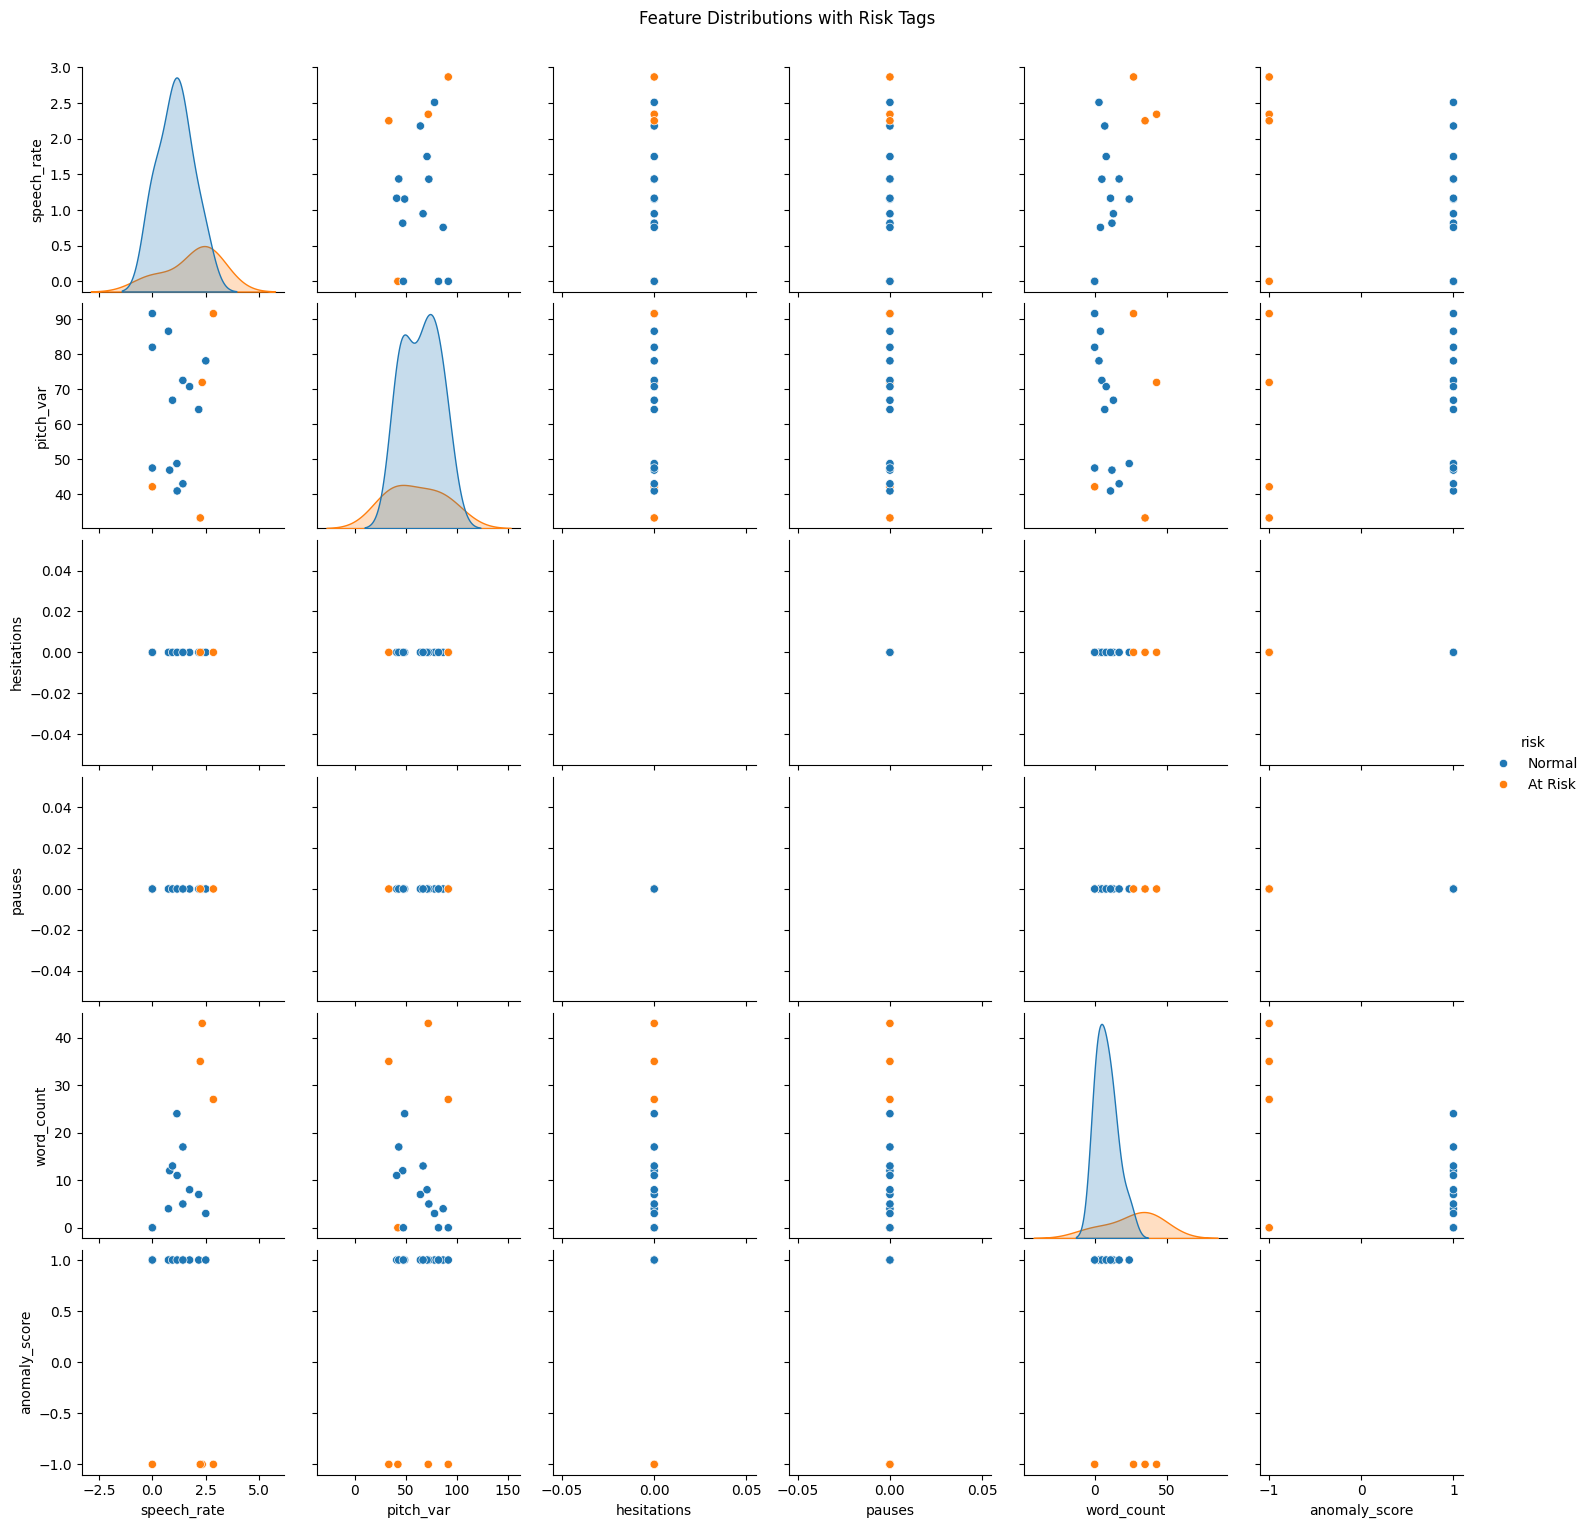

In [44]:
sns.pairplot(df_features, hue='risk')
plt.suptitle("Feature Distributions with Risk Tags", y=1.02)
plt.show()


In [45]:
print(df_features.columns)


Index(['speech_rate', 'pitch_var', 'hesitations', 'pauses', 'word_count',
       'anomaly_score', 'risk'],
      dtype='object')


**8. Optional: Risk Score Function**

In [46]:
def get_cognitive_score(audio_path):
    text = transcribe_audio(audio_path)
    features = extract_audio_features(audio_path, text)
    input_df = pd.DataFrame([features])
    input_scaled = scaler.transform(input_df)
    risk = model.predict(input_scaled)
    return "At Risk" if risk[0] == -1 else "Normal"

# Example usage:
# print(get_cognitive_score("voice_clips/sample1.wav"))
    print(get_cognitive_score("voice_clips/sample1.wav"))

# **Additional**

Boxplot to Visualize Feature Distributions:

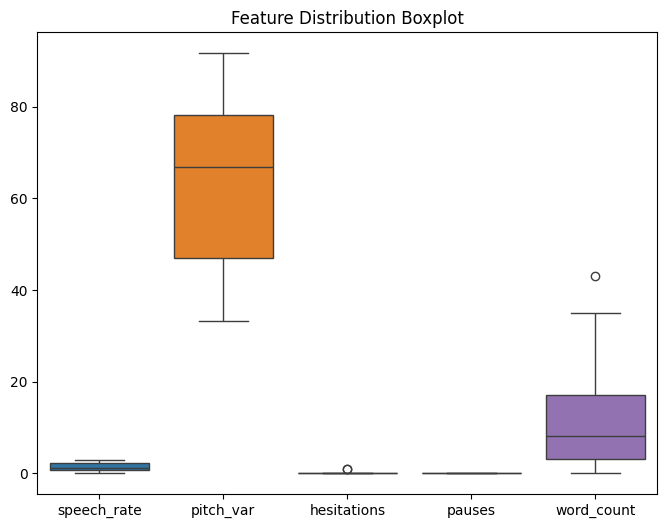

In [54]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_features.drop(columns=['anomaly_score'], errors='ignore'))
plt.title('Feature Distribution Boxplot')
plt.show()


Histogram for Each Feature:

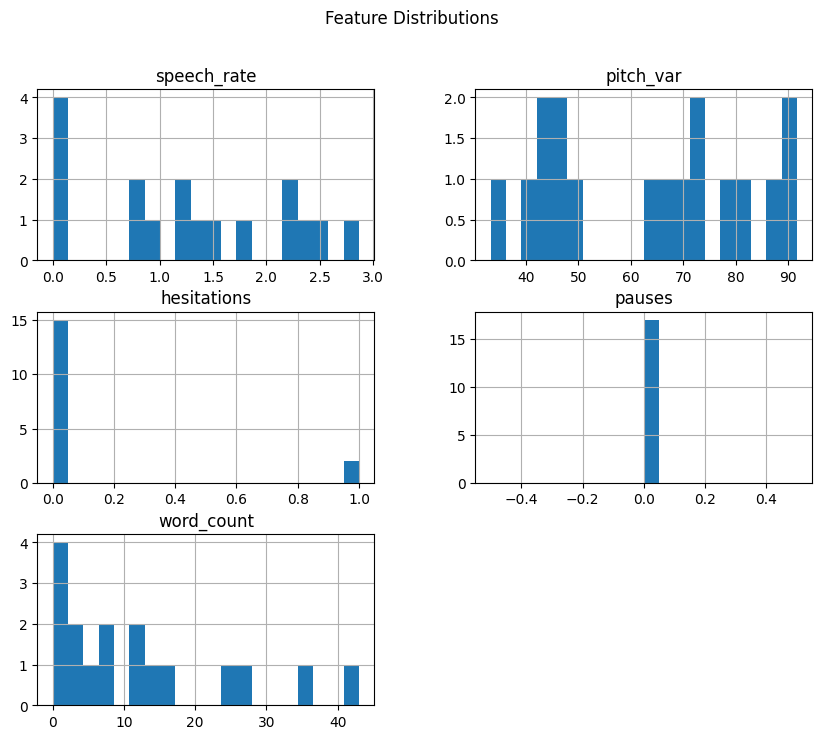

In [55]:
df_features.drop(columns=['anomaly_score'], errors='ignore').hist(figsize=(10, 8), bins=20)
plt.suptitle('Feature Distributions')
plt.show()


## 🧠**Voice-Based Cognitive Decline Detection – Final Report**
### 1. Most Insightful Features
- **Speech Rate**: Slower speech may correlate with cognitive stress.
- **Pitch Variability**: Low pitch variation can reflect flat or strained delivery.
- **Hesitations (um, uh)**: Increased hesitations signal uncertainty or word-recall issues.
- **Pauses**: Proxy for difficulty in sentence formulation.

### 2. ML Method Used
- **Unsupervised Model**: Isolation Forest

1.   List item
2.   List item


- **Why?**: Since labels for "at risk" vs "normal" are unavailable, we used this to identify outliers in feature space.

### 3. Results Summary
- Audio files tagged with 'At Risk' based on outlier detection.
- Pairplot shows some separation based on speech patterns and variance.

### 4. Future Improvements
- Use larger, clinically labeled datasets.
- Include more advanced features: sentiment, syntactic complexity.
- Integrate deep audio models like wav2vec or Whisper for better transcription.
- Collaborate with cognitive science experts for evaluation.
